--- CLEAN DATA REPORT ---
[6.0Hz.csv ] Windows: 39/76 kept ( 51.3%)
[6.66Hz.csv] Windows: 32/68 kept ( 47.1%)
[7.5Hz.csv ] Windows: 167/231 kept ( 72.3%)
[8.57Hz.csv] Windows: 16/84 kept ( 19.0%)
[10.0Hz.csv] Windows: 16/107 kept ( 15.0%)
[12.0Hz.csv] Windows: 22/66 kept ( 33.3%)
[15.0Hz.csv] Windows: 9/86 kept ( 10.5%)
[20.0Hz.csv] Windows: 6/63 kept (  9.5%)
[30.0Hz.csv] Windows: 44/106 kept ( 41.5%)


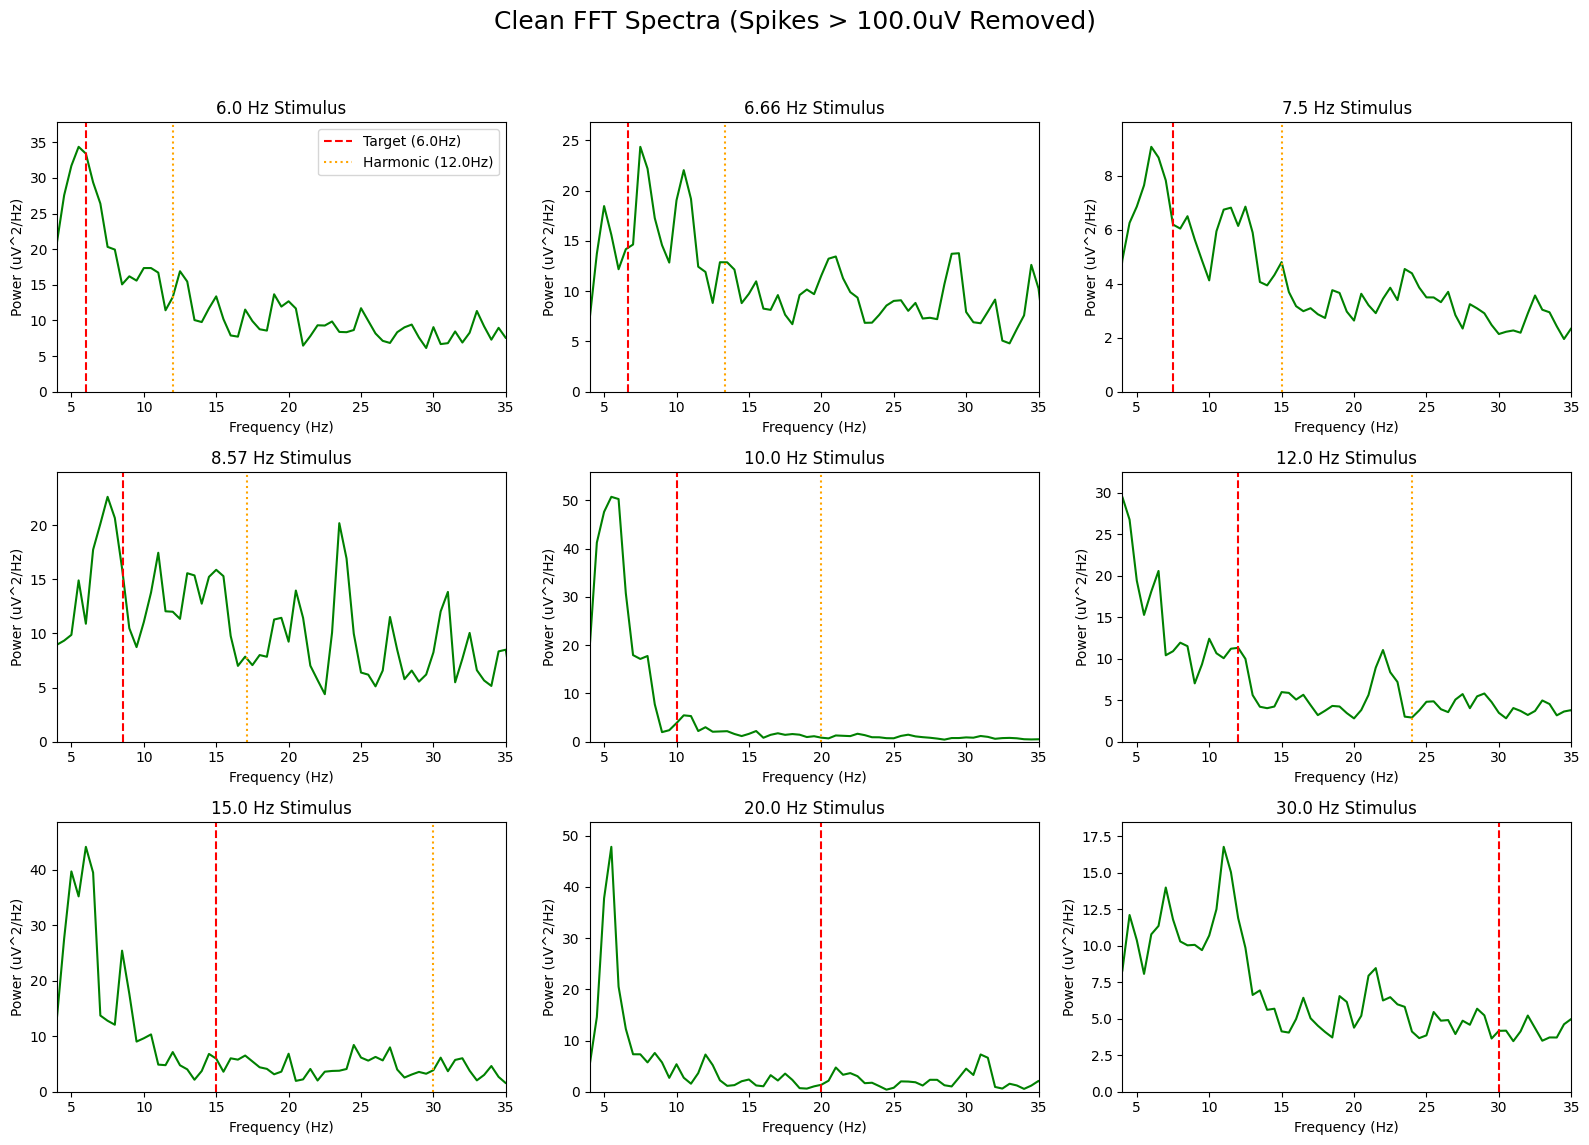

In [4]:
import os
import pandas as pd
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
DATA_DIR = '../OPEN_BCI/data/bad_data'
TEST_FILES =[
    '6.0Hz.csv', '6.66Hz.csv', '7.5Hz.csv',
    '8.57Hz.csv', '10.0Hz.csv', '12.0Hz.csv',
    '15.0Hz.csv', '20.0Hz.csv', '30.0Hz.csv'
]
# Ensure these are the channels on the back of the head!
TARGET_CHANNELS = ['Channel_6', 'Channel_7']
FS = 250.0

# --- ARTIFACT REJECTION SETTINGS ---
VOLTAGE_THRESHOLD = 100.0  # Delete any window with a spike over 100 uV
WINDOW_SEC = 2.0           # 2-second windows (Provides perfect 0.5 Hz resolution)
STEP_SEC = 0.5             # Slide forward by 0.5 seconds (Overlapping)
# =================================================

def process_file_with_overlap(filepath):
    """Loads data, applies overlapping epoch rejection, and returns clean FFT."""
    df = pd.read_csv(filepath)

    # 1. Extract and Average the Target Channels
    raw_data = np.zeros(len(df) - int(FS*3)) # Prepare array, minus first 3 seconds
    valid_channels = 0

    for ch in TARGET_CHANNELS:
        if ch in df.columns:
            # Skip first 3 seconds to let amplifier settle
            ch_data = df[ch].values[int(FS*3):]

            # Check if channel is "dead" (values near zero)
            if np.mean(np.abs(ch_data)) > 1e-6:
                # Ensure arrays match in length (in case of slight mismatches)
                min_len = min(len(raw_data), len(ch_data))
                raw_data[:min_len] += ch_data[:min_len]
                valid_channels += 1

    if valid_channels == 0:
        return None, None, 0, 0

    raw_data = raw_data / valid_channels

    # 2. High-Pass Filter (Must be done BEFORE artifact checking!)
    # Removes the massive natural baseline drift so data centers at 0 uV.
    b, a = signal.butter(4, 2.0, btype='highpass', fs=FS)
    clean_data = signal.filtfilt(b, a, raw_data)

    # 3. Chop into Overlapping Blocks & Reject Artifacts
    samples_per_window = int(FS * WINDOW_SEC)
    step_size = int(FS * STEP_SEC)

    accepted_windows =[]
    total_windows = 0

    # Slide the window forward step-by-step
    for start in range(0, len(clean_data) - samples_per_window + 1, step_size):
        end = start + samples_per_window
        window_data = clean_data[start:end]
        total_windows += 1

        # Find absolute peak voltage in this specific 2-second block
        max_voltage = np.max(np.abs(window_data))

        # If the block is quiet, keep it!
        if max_voltage < VOLTAGE_THRESHOLD:
            accepted_windows.append(window_data)

    # 4. Perform FFT on the surviving data
    if len(accepted_windows) == 0:
        return None, None, total_windows, 0 # File was 100% junk

    all_powers =[]
    freqs = None

    # Calculate Welch's FFT for every single clean block
    for window in accepted_windows:
        # nperseg=samples_per_window gives us exactly 0.5 Hz resolution
        f, p = signal.welch(window, fs=FS, nperseg=samples_per_window)
        freqs = f
        all_powers.append(p)

    # Average all the clean FFTs together into one super-clean graph
    avg_power = np.mean(all_powers, axis=0)

    return freqs, avg_power, total_windows, len(accepted_windows)

# ================= MAIN SCRIPT =================
print("--- CLEAN DATA REPORT ---")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle(f'Clean FFT Spectra (Spikes > {VOLTAGE_THRESHOLD}uV Removed)', fontsize=18)
axes = axes.flatten()

for idx, filename in enumerate(TEST_FILES):
    filepath = os.path.join(DATA_DIR, filename)
    target_hz = float(filename.replace('Hz.csv', ''))
    ax = axes[idx]

    if not os.path.exists(filepath):
        print(f"[{filename}] File not found.")
        ax.set_title(f"{filename} (Not Found)")
        continue

    # Process the data
    freqs, stim_power, total_win, clean_win = process_file_with_overlap(filepath)

    if total_win > 0:
        percent_clean = (clean_win / total_win) * 100
        print(f"[{filename:^10}] Windows: {clean_win}/{total_win} kept ({percent_clean:5.1f}%)")
    else:
        print(f"[{filename:^10}] Dead channels or insufficient data.")

    # Plotting
    if freqs is not None and clean_win > 0:
        ax.plot(freqs, stim_power, color='green', linewidth=1.5)

        # Draw Target and Harmonic Markers
        ax.axvline(x=target_hz, color='red', linestyle='--', label=f'Target ({target_hz}Hz)')
        ax.axvline(x=target_hz*2, color='orange', linestyle=':', label=f'Harmonic ({target_hz*2}Hz)')

        ax.set_xlim(4, 35)

        # Dynamically set Y limit based on clean data
        valid_idx = (freqs >= 4) & (freqs <= 35)
        max_y = np.max(stim_power[valid_idx])
        ax.set_ylim(0, max_y * 1.1)

    else:
        # If all data was rejected, show a blank red graph
        ax.text(0.5, 0.5, '100% OF DATA REJECTED\n(Too much noise)',
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, color='red', fontsize=12, weight='bold')
        ax.set_xlim(4, 35)

    ax.set_title(f"{target_hz} Hz Stimulus")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power (uV^2/Hz)")

    if idx == 0:
        ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()